In [20]:
using LinearAlgebra, Plots

In [24]:
a = 1.0
#k = range(0.01, stop=π/a - 0.01, length=500)
k_acoustic_range = range(0.01, stop=π/a - 0.01, length=500)
k_optical_range = range(π/a + 0.01, stop=2*π/a - 0.01, length=500)

1/ sin.(k_acoustic_range .*a)
1/ sin.(k_optical_range .*a)

1×500 transpose(::Vector{Float64}) with eltype Float64:
 -3.98243e-5  -6.47355e-5  -8.96441e-5  …  -6.47355e-5  -3.98243e-5

In [27]:
m = 1.0
Δk = 0.1

k_red = 1 - (Δk)^2
k_center = 1.0

omega_squared_plus =   (2*k_center / m) .* ( 1  .+ sqrt.( 1 .- ( k_red  / k_center).*(sin.(k_optical_range.*a) ).^2 ) )
omega_squared_minus = (2*k_center /m) .* ( 1  .- sqrt.( 1 .- ( k_red  / k_center).*(sin.(k_acoustic_range.*a) ).^2 ) )

500-element Vector{Float64}:
 9.899915025202155e-5
 0.00026159926496949204
 0.0005016733824771968
 0.0008192118257328573
 0.0012142017950107498
 0.001686627368243876
 0.0022364695014496228
 0.002863706029237134
 0.003568311665399504
 0.004350258003587237
 ⋮
 0.003568311665399504
 0.002863706029237134
 0.0022364695014496228
 0.001686627368243876
 0.0012142017950107498
 0.0008192118257328573
 0.0005016733824771968
 0.00026159926496949204
 9.899915025202155e-5

In [31]:
omega_squared_minus

500-element Vector{Float64}:
 9.899915025202155e-5
 0.00026159926496949204
 0.0005016733824771968
 0.0008192118257328573
 0.0012142017950107498
 0.001686627368243876
 0.0022364695014496228
 0.002863706029237134
 0.003568311665399504
 0.004350258003587237
 ⋮
 0.003568311665399504
 0.002863706029237134
 0.0022364695014496228
 0.001686627368243876
 0.0012142017950107498
 0.0008192118257328573
 0.0005016733824771968
 0.00026159926496949204
 9.899915025202155e-5

In [32]:
omega_squared_plus

500-element Vector{Float64}:
 3.999901000849748
 3.9997384007350307
 3.999498326617523
 3.999180788174267
 3.998785798204989
 3.998313372631756
 3.9977635304985504
 3.9971362939707626
 3.9964316883346007
 3.995649741996413
 ⋮
 3.9964316883346003
 3.9971362939707626
 3.99776353049855
 3.998313372631756
 3.998785798204989
 3.999180788174267
 3.999498326617523
 3.9997384007350303
 3.999901000849748

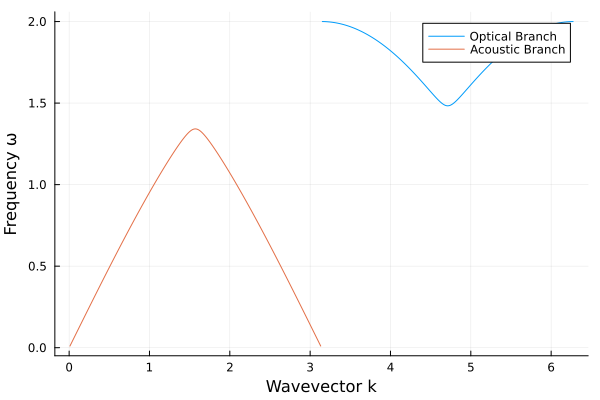

In [34]:
plot(k_optical_range, sqrt.(omega_squared_plus), label="Optical Branch", xlabel="Wavevector k", ylabel="Frequency ω", legend=:topright)
plot!(k_acoustic_range, sqrt.(omega_squared_minus), label="Acoustic Branch")

In [ ]:
# Plotting the extended zone scheme
k_acoustic = vcat(k .- 2π/a, k, k .+ 2π/a)
k_optical = vcat(k .- 2π/a, k, k .+ 2π/a)

In [3]:
function build_dynamical_matrix(k::Vector{Float64}, m::Vector{Float64}, boundary_condition::Symbol = :fixed)
    N = length(m)
    D = zeros(N, N)

    if boundary_condition == :fixed
        for i in 1:N
            D[i,i] += (k[i]+ k[i+1]) / m[i]
            if i > 1
                D[i, i-1] = -k[i] / sqrt(m[i] * m[i-1])
            end
            if i < N
                D[i, i+1] = -k[i+1] / sqrt(m[i] * m[i+1])
            end
        end
    elseif boundary_condition == :periodic
        for i in 1:N
            D[i,i] += (k[i]+ k[mod1(i+1, N)]) / m[i]
            D[i, mod1(i-1, N)] = -k[i] / sqrt(m[i] * m[mod1(i-1, N)])
            D[i, mod1(i+1, N)] = -k[mod1(i+1, N)] / sqrt(m[i] * m[mod1(i+1, N)])
        end
    else
        error("Unsupported boundary condition: $boundary_condition")
    
    end


    return D
end

build_dynamical_matrix (generic function with 2 methods)

In [11]:
N = 64
DeltaK = 0.1
k = [1.0 + DeltaK * (-1.0)^(i-1) for i in 1:N]
m = ones(N)

64-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [17]:
eigenvalues, eigenvectors = eigen(build_dynamical_matrix(k, m, :periodic))

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
64-element Vector{Float64}:
 0.0
 0.009534010539643013
 0.009534010539643596
 0.038041418792855594
 0.03804141879285566
 0.08523896207410803
 0.08523896207411098
 0.15065648762881964
 0.15065648762882275
 0.23363960037063483
 ⋮
 3.849343512371177
 3.8493435123711777
 3.9147610379258917
 3.9147610379258926
 3.9619585812071434
 3.9619585812071443
 3.9904659894603562
 3.9904659894603562
 4.0
vectors:
64×64 Matrix{Float64}:
 -0.125  -0.0176323   0.175895   …  -0.0457038    0.170766   -0.125
 -0.125  -0.0364934   0.172969       0.0270264   -0.174699    0.125
 -0.125  -0.0516089   0.169075      -0.0115107    0.176402   -0.125
 -0.125  -0.0695367   0.162526      -0.00757489  -0.176614    0.125
 -0.125  -0.0836023   0.155758       0.0231247    0.175258   -0.125
 -0.125  -0.0999078   0.145837   …  -0.0418851   -0.171743    0.125
 -0.125  -0.112383    0.136455       0.0568714    0.167379   -0.125
 -0.125  -0.12644     0.123544    

In [24]:
2* eigenvalues[2]


0.019068021079286027

In [23]:
eigenvalues[N]

4.0

In [14]:
function find_normal_modes(k::Vector{Float64}, m::Vector{Float64})
    D = build_dynamical_matrix(k, m)
    λ, V = eigen(D)
    frequencies = sqrt.(abs.(λ))
    #return frequencies, V
end

find_normal_modes (generic function with 1 method)

In [15]:
frequencies, modes = find_normal_modes(k, m)
#println("Frequencies: ", frequencies[1:10])

BoundsError: BoundsError: attempt to access 64-element Vector{Float64} at index [65]

In [15]:
function run_simulation(v0, q0, tspan, k, m, alpha, beta, DT, forces)
    prob = SecondOrderODEProblem(FPUTEquations.fput_generalized, v0, q0, tspan, (k, m, alpha, beta, forces))
    # Save solution every 2 time steps to balance memory and resolution
    saveat = 0.0:2*DT:tspan[2]
    return solve(prob, KahanLi8(), dt=DT, saveat=saveat)
end

run_simulation (generic function with 1 method)

In [ ]:
function fput_generalized(dv, v, q, p, t)
    k, m, alpha, beta, forces = p
    N = length(m)
    forces .= 0.0 # Reset the forces array
    for i in 2:N-1
        dl = q[i] - q[i-1]
        dr = q[i+1] - q[i]
        forces[i] = k[i+1]*dr - k[i]*dl + alpha*(k[i+1]*dr^2 - k[i]*dl^2) + beta*(k[i+1]*dr^3 - k[i]*dl^3)
    end
    forces[1] = -k[1]*q[1] + k[2]*(q[2] - q[1]) + alpha*(k[2]*(q[2]-q[1])^2 - k[1]*q[1]^2) + beta*(k[2]*(q[2]-q[1])^3 - k[1]*q[1]^3)
    forces[N] = -k[N+1]*q[N] + k[N]*(q[N-1] - q[N]) + alpha*(-k[N]*(q[N-1]-q[N])^2 + k[N+1]*q[N]^2) + beta*(-k[N]*(q[N-1]-q[N])^3 - k[N+1]*q[N]^3)
    dv .= forces ./ m
end


In [16]:
function initialize_spring_constants(N::Int, DeltaK::Float64, boundary_condition::Symbol = :fixed)
    if boundary_condition == :fixed
        k = 1 .+ DeltaK .* (-1) .^ mod.(0:N, 2)
    elseif boundary_condition == :periodic
        #k = ones(N)
        #k = vcat(k, k[1])  # Close the loop for periodic BC
        k = 1 .+ DeltaK .* (-1) .^ mod.(0:N-1, 2)
        k = vcat(k, k[1])  # Close the loop for periodic BC
    else
        error("Unsupported boundary condition: $boundary_condition")
    end
    return k
end

initialize_spring_constants (generic function with 2 methods)

In [19]:
initialize_spring_constants(5, 0.1, :periodic)

6-element Vector{Float64}:
 1.1
 0.9
 1.1
 0.9
 1.1
 1.1

In [ ]:
function fput_generalized(dv, v, q, p, t)
    k, m, alpha, beta, forces = p
    N = length(m)
    forces .= 0.0 # Reset the forces array

    # Compute forces with nonlinear terms and different boundary conditions

    if length(k) == N + 1 # Fixed boundary conditions
        for i in 2:N-1
            dl = q[i] - q[i-1]
            dr = q[i+1] - q[i]
            forces[i] = k[i+1]*dr - k[i]*dl + alpha*(k[i+1]*dr^2 - k[i]*dl^2) + beta*(k[i+1]*dr^3 - k[i]*dl^3)
        end
        forces[1] = -k[1]*q[1] + k[2]*(q[2] - q[1]) + alpha*(k[2]*(q[2]-q[1])^2 - k[1]*q[1]^2) + beta*(k[2]*(q[2]-q[1])^3 - k[1]*q[1]^3)
        forces[N] = -k[N+1]*q[N] + k[N]*(q[N-1] - q[N]) + alpha*(-k[N]*(q[N-1]-q[N])^2 + k[N+1]*q[N]^2) + beta*(-k[N]*(q[N-1]-q[N])^3 - k[N+1]*q[N]^3)
    elseif length(k) == N # Periodic boundary conditions
        for i in 1:N
            dl = q[i] - q[mod1(i-1, N)]
            dr = q[mod1(i+1, N)] - q[i]
            forces[i] = k[mod1(i+1, N)]*dr - k[i]*dl + alpha*(k[mod1(i+1, N)]*dr^2 - k[i]*dl^2) + beta*(k[mod1(i+1, N)]*dr^3 - k[i]*dl^3)
        end
    else
        error("Inconsistent k and m lengths for boundary conditions.")
    end

    #for i in 2:N-1
    #    dl = q[i] - q[i-1]
    #    dr = q[i+1] - q[i]
    #    forces[i] = k[i+1]*dr - k[i]*dl + alpha*(k[i+1]*dr^2 - k[i]*dl^2) + beta*(k[i+1]*dr^3 - k[i]*dl^3)
    #end
    #forces[1] = -k[1]*q[1] + k[2]*(q[2] - q[1]) + alpha*(k[2]*(q[2]-q[1])^2 - k[1]*q[1]^2) + beta*(k[2]*(q[2]-q[1])^3 - k[1]*q[1]^3)
    #forces[N] = -k[N+1]*q[N] + k[N]*(q[N-1] - q[N]) + alpha*(-k[N]*(q[N-1]-q[N])^2 + k[N+1]*q[N]^2) + beta*(-k[N]*(q[N-1]-q[N])^3 - k[N+1]*q[N]^3)
    
    dv .= forces ./ m
end

In [ ]:
function run_and_analyze(sim_params)
    # Unpack parameters: N, alpha, beta, TMAX, DT, tspan, k, m

    N = sim_params[:N]
    alpha = sim_params[:alpha]
    beta = sim_params[:beta]
    TMAX = sim_params[:TMAX]
    DT = sim_params[:DT] 

    k = sim_params[:k]
    m = sim_params[:m]

    return N, alpha, beta, TMAX, DT, k, m
end

run_and_analyze (generic function with 1 method)

In [ ]:
N, alpha, beta, TMAX, DT, k, m = run_and_analyze()

In [2]:
N, alpha, beta, TMAX, DT, k, m = 32, 0.0, 0.0, 100.0, 0.1, zeros(32), zeros(32)

(32, 0.0, 0.0, 100.0, 0.1, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [ ]:
sim_params = Dict([("N", N), ("alpha", alpha), ()] )

Dict{String, Real} with 2 entries:
  "N"     => 32
  "alpha" => 0.0

In [16]:
sim_params["alpha"]

0.0

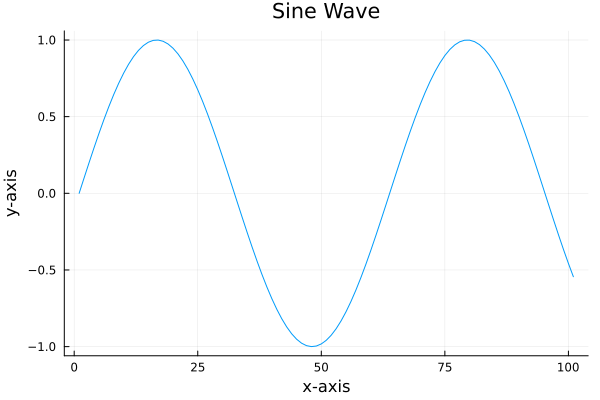

In [4]:
# Plot testing 

y = sin.(0:0.1:10)
using Plots
plot(y, xlabel="x-axis", ylabel="y-axis", title="Sine Wave", label=false)

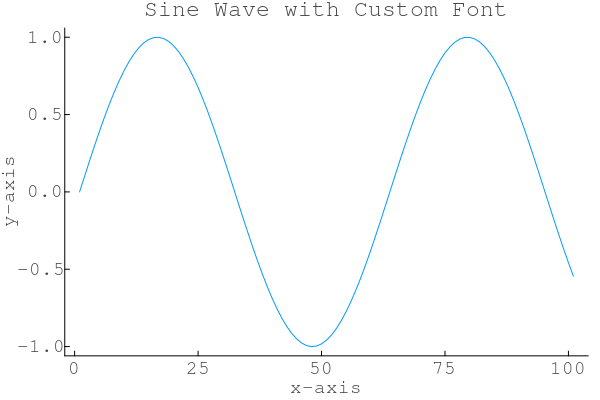

In [12]:
# Changing the font of the plots
default(titlefont=font(12, "Latin Modern Roman"), guidefont=font(10, "Latin Modern Roman"), tickfont=font(10, "Latin Modern Roman"))
plot(y, xlabel="x-axis", ylabel="y-axis", title="Sine Wave with Custom Font", label=false, grid=false)

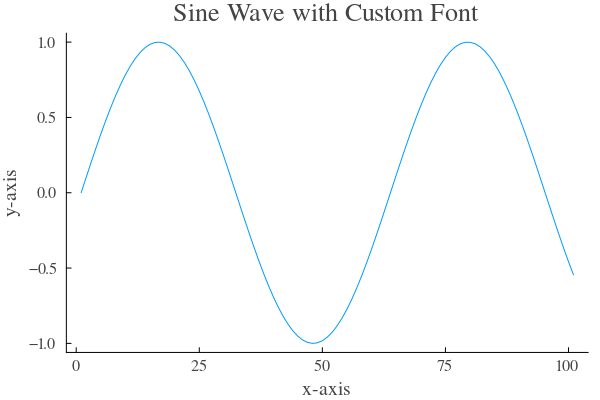

In [14]:
default(titlefont=font(16, "Times"), guidefont=font(12, "Times"), tickfont=font(10, "Times"))
plot(y, xlabel="x-axis", ylabel="y-axis", title="Sine Wave with Custom Font", label=false, grid=false)


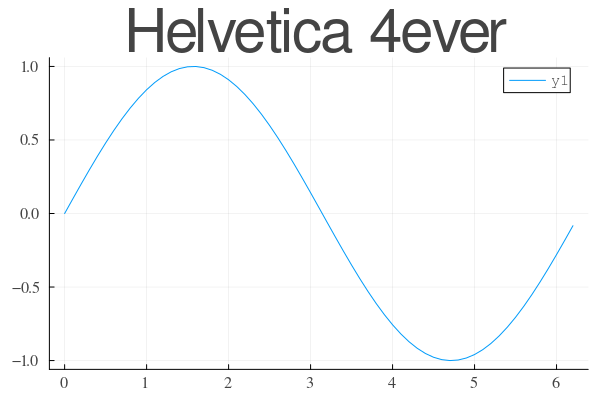

In [15]:
# Source - https://stackoverflow.com/a
# Posted by daycaster, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-26, License - CC BY-SA 4.0

using Plots
x = 0:0.1:2π
y = sin.(x)
plotfonts = Plots.font(40, "Helvetica")
plot(x, y, title="Helvetica 4ever", titlefont = plotfonts)


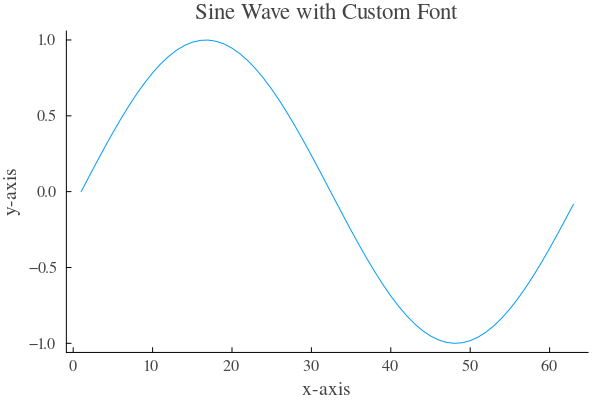

In [18]:
titlefont =  Plots.font(14, "Times")
plot(y, xlabel="x-axis", ylabel="y-axis", title="Sine Wave with Custom Font", titlefont=titlefont, label=false, grid=false)

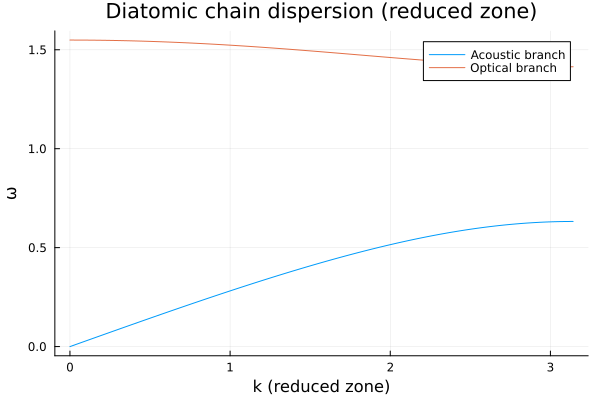

In [1]:
# Diatomic chain dispersion (equal masses, alternating springs)
using Plots
a = 1.0
m = 1.0
k1 = 1.0  # spring inside unit cell
k2 = 0.2  # spring between cells (different)
ks = range(0, stop=π/a, length=500)  # reduced Brillouin zone
discr = (k1 + k2)^2 .- 4*k1*k2 .* sin.(ks .* a ./ 2).^2
sqrtterm = sqrt.(max.(discr, 0.0))
omega2_plus = ((k1 + k2)/m) .+ sqrtterm ./ m
omega2_minus = ((k1 + k2)/m) .- sqrtterm ./ m
omega_plus = sqrt.(omega2_plus)
omega_minus = sqrt.(max.(omega2_minus, 0.0))
plot(ks, omega_minus, label="Acoustic branch", xlabel="k (reduced zone)", ylabel="ω", legend=:topright)
plot!(ks, omega_plus, label="Optical branch")
title!("Diatomic chain dispersion (reduced zone)")